# Анализ пролонгаций 2023

Расчёт коэффициентов пролонгации K1 (первый месяц) и K2 (второй месяц) по данным отдела за 2023 год.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


## 1. Загрузка и парсинг данных

In [2]:
prol = pd.read_csv('prolongations.csv')
fin  = pd.read_csv('financial_data.csv')

month_columns = [
    'Ноябрь 2022', 'Декабрь 2022',
    'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023',
    'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023',
    'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023',
    'Январь 2024', 'Февраль 2024'
]
month_mapping = {m.lower(): m for m in month_columns}
target_months = [
    'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023',
    'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023',
    'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023',
]
month_short = {
    'Январь 2023':'Янв', 'Февраль 2023':'Фев', 'Март 2023':'Мар',
    'Апрель 2023':'Апр', 'Май 2023':'Май',    'Июнь 2023':'Июн',
    'Июль 2023':'Июл',  'Август 2023':'Авг',  'Сентябрь 2023':'Сен',
    'Октябрь 2023':'Окт','Ноябрь 2023':'Ноя', 'Декабрь 2023':'Дек',
}
print(f'prolongations: {len(prol)} строк, financial_data: {len(fin)} строк')


prolongations: 477 строк, financial_data: 451 строк


## 2. Парсинг значений ячеек

In [3]:
def parse_amount(val):
    """Парсит значение ячейки: число / 'стоп' / 'end' / 'в ноль' / None"""
    if pd.isna(val) or str(val).strip() == '': return None
    s = str(val).strip().lower()
    if s in ['стоп', 'end']: return 'stop'
    if s == 'в ноль':        return 'zero'
    try:
        return float(s.replace('\xa0','').replace(' ','').replace(',','.'))
    except:
        return None

for col in month_columns:
    fin[col + '_p'] = fin[col].apply(parse_amount)

print('Парсинг завершён')


Парсинг завершён


## 3. Агрегация финансовых данных по проектам

In [4]:
project_data = {}
for pid, grp in fin.groupby('id'):
    info = {'id': pid, 'has_stop': False, 'stop_month': None,
            'shipment': {}, 'is_zero': {}}
    for m in month_columns:
        vals = grp[m + '_p'].tolist()
        if any(v == 'stop' for v in vals if v is not None) and info['stop_month'] is None:
            info['has_stop'] = True
            info['stop_month'] = m
        nums  = [v for v in vals if isinstance(v, float)]
        all_z = (all(v == 'zero' for v in vals if v is not None)
                 and not nums
                 and any(v == 'zero' for v in vals if v is not None))
        info['shipment'][m] = sum(nums) if nums else 0.0
        info['is_zero'][m]  = all_z
    project_data[pid] = info

prol_clean = prol.drop_duplicates(subset=['id', 'month']).copy()
prol_clean['month_col'] = prol_clean['month'].str.lower().map(month_mapping)

print(f'Проектов агрегировано: {len(project_data)}')
print(f'Пролонгаций (дедупл.): {len(prol_clean)}')


Проектов агрегировано: 314
Пролонгаций (дедупл.): 473


## 4. Вспомогательные функции

In [5]:
def is_stopped(pid, month_col):
    """True если у проекта стоп в month_col или раньше."""
    if pid not in project_data: return True
    p = project_data[pid]
    if not p['has_stop']: return False
    return month_columns.index(p['stop_month']) <= month_columns.index(month_col)


def get_raw_shipment(pid, month_col):
    """
    Возвращает отгрузку проекта за месяц:
    - None: проект остановлен / нет данных
    - 0.0:  'в ноль'
    - float: реальная сумма
    """
    if pid not in project_data: return None
    p = project_data[pid]
    if p['has_stop'] and p['stop_month']:
        if month_columns.index(p['stop_month']) <= month_columns.index(month_col):
            return None
    amt = p['shipment'].get(month_col, 0.0)
    if p['is_zero'].get(month_col, False): return 0.0
    return amt if amt > 0 else None


def get_base_amount(pid, month_col):
    """
    База для коэффициента.
    ИСПРАВЛЕНИЕ: если месяц = 'в ноль' → рекурсивно берём предыдущий месяц.
    """
    if pid not in project_data: return 0.0
    p = project_data[pid]
    if p['is_zero'].get(month_col, False):
        idx = month_columns.index(month_col)
        return get_base_amount(pid, month_columns[idx - 1]) if idx > 0 else 0.0
    raw = get_raw_shipment(pid, month_col)
    return raw if raw is not None else 0.0


def is_prolonged(pid, month_col):
    """
    True если проект пролонгирован в month_col.
    ИСПРАВЛЕНИЕ: 'в ноль' в целевом месяце = проект активен (пролонгирован),
    сумма пролонгации берётся из предыдущего месяца через get_base_amount.
    """
    if pid not in project_data: return False
    p = project_data[pid]
    if p['has_stop']:
        si = month_columns.index(p['stop_month']) if p['stop_month'] else -1
        if si <= month_columns.index(month_col): return False
    if p['is_zero'].get(month_col, False): return True
    return p['shipment'].get(month_col, 0.0) > 0


print('Функции определены')


Функции определены


## 5. Основной расчёт K1 и K2

In [6]:
results = []

for tm in target_months:
    ti = month_columns.index(tm)
    m1 = month_columns[ti - 1] if ti > 0 else None  
    m2 = month_columns[ti - 2] if ti > 1 else None   
    if m1:
        for _, row in prol_clean[prol_clean['month_col'] == m1].iterrows():
            pid, am = row['id'], row['AM']
            if is_stopped(pid, m1) or pid not in project_data:
                continue
            base = get_base_amount(pid, m1)
            pr   = is_prolonged(pid, tm)
            pamt = get_base_amount(pid, tm) if pr else 0.0
            results.append({
                'target_month': tm, 'coeff_type': 1,
                'project_id': pid, 'AM': am,
                'ended_month': m1, 'base_amount': base,
                'prolonged': pr, 'prolonged_amount': pamt,
            })

    if m2 and m1:
        for _, row in prol_clean[prol_clean['month_col'] == m2].iterrows():
            pid, am = row['id'], row['AM']
            if is_stopped(pid, m2) or pid not in project_data:
                continue
            if is_prolonged(pid, m1):       
                continue
            base = get_base_amount(pid, m2)
            pr   = is_prolonged(pid, tm)
            pamt = get_base_amount(pid, tm) if pr else 0.0
            results.append({
                'target_month': tm, 'coeff_type': 2,
                'project_id': pid, 'AM': am,
                'ended_month': m2, 'base_amount': base,
                'prolonged': pr, 'prolonged_amount': pamt,
            })

res = pd.DataFrame(results)
d1  = res[res['coeff_type'] == 1]
d2  = res[res['coeff_type'] == 2]
print(f'K1: {len(d1)} записей  |  K2: {len(d2)} записей')
print(f'Всего проектов K1: {d1["project_id"].nunique()}  |  K2: {d2["project_id"].nunique()}')


K1: 335 записей  |  K2: 173 записей
Всего проектов K1: 231  |  K2: 158


## 6. Агрегация и расчёт коэффициентов

In [7]:
def calc(df):
    base  = df['base_amount'].sum()
    prol  = df[df['prolonged']]['prolonged_amount'].sum()
    coeff = prol / base if base > 0 else np.nan
    return pd.Series({
        'base_sum':          base,
        'prolonged_sum':     prol,
        'coefficient':       coeff,
        'total_projects':    len(df),
        'prolonged_projects': int(df['prolonged'].sum()),
    })

mo = {m: i for i, m in enumerate(target_months)}

k1_am_month   = d1.groupby(['AM', 'target_month']).apply(calc).reset_index()
k2_am_month   = d2.groupby(['AM', 'target_month']).apply(calc).reset_index()
k1_dept_month = d1.groupby('target_month').apply(calc).reset_index()
k2_dept_month = d2.groupby('target_month').apply(calc).reset_index()
k1_am_year    = d1.groupby('AM').apply(calc).reset_index()
k2_am_year    = d2.groupby('AM').apply(calc).reset_index()
k1_year       = calc(d1)
k2_year       = calc(d2)

for df_ in [k1_dept_month, k2_dept_month]:
    df_['_o'] = df_['target_month'].map(mo)
    df_.sort_values('_o', inplace=True)
    df_.drop('_o', axis=1, inplace=True)
    df_.reset_index(drop=True, inplace=True)

print('Агрегация завершена')


Агрегация завершена


## 7. Результаты — Коэффициент 1

In [8]:
print('=' * 58)
print('КОЭФФИЦИЕНТ 1 — ОТДЕЛ ПО МЕСЯЦАМ')
print(f'{"Месяц":<16} {"Коэфф":>6}  {"Пролонг (руб)":>15}  {"База (руб)":>15}  {"Проектов":>9}')
print('-' * 58)
for _, r in k1_dept_month.iterrows():
    sh = month_short[r['target_month']]
    print(f"{sh:<16} {r['coefficient']:>6.1%}  "
          f"{r['prolonged_sum']:>15,.0f}  {r['base_sum']:>15,.0f}  "
          f"{int(r['prolonged_projects']):>4}/{int(r['total_projects']):<4}")
print('-' * 58)
print(f"{'ГОД':<16} {k1_year['coefficient']:>6.1%}  "
      f"{k1_year['prolonged_sum']:>15,.0f}  {k1_year['base_sum']:>15,.0f}  "
      f"{int(k1_year['prolonged_projects']):>4}/{int(k1_year['total_projects']):<4}")


КОЭФФИЦИЕНТ 1 — ОТДЕЛ ПО МЕСЯЦАМ
Месяц             Коэфф    Пролонг (руб)       База (руб)   Проектов
----------------------------------------------------------
Янв               45.9%        2,748,022        5,986,767    24/53  
Фев               78.3%        2,660,945        3,400,076     7/20  
Мар               64.6%        1,108,904        1,716,453    12/25  
Апр               39.9%        1,501,923        3,762,484    16/31  
Май               58.0%        1,981,262        3,414,632    17/24  
Июн               22.1%          281,673        1,274,626     3/21  
Июл               52.4%        1,390,411        2,650,983    14/30  
Авг               48.7%          943,679        1,936,916    12/22  
Сен               34.9%        1,086,504        3,113,823    10/24  
Окт               81.8%        3,014,655        3,686,851    20/37  
Ноя               51.8%          811,594        1,567,140    10/19  
Дек               54.5%        1,325,978        2,434,795    14/29  
-----------

## 8. Результаты — Коэффициент 2

In [10]:
print('=' * 58)
print('КОЭФФИЦИЕНТ 2 — ОТДЕЛ ПО МЕСЯЦАМ')
print(f'{"Месяц":<16} {"Коэфф":>6}  {"Пролонг (руб)":>15}  {"База (руб)":>15}  {"Проектов":>9}')
print('-' * 58)
for _, r in k2_dept_month.iterrows():
    sh = month_short[r['target_month']]
    c  = f"{r['coefficient']:.1%}" if pd.notna(r['coefficient']) else '  —'
    print(f"{sh:<16} {c:>6}  "
          f"{r['prolonged_sum']:>15,.0f}  {r['base_sum']:>15,.0f}  "
          f"{int(r['prolonged_projects']):>4}/{int(r['total_projects']):<4}")
print('-' * 58)
print(f"{'ГОД':<16} {k2_year['coefficient']:>6.1%}  "
      f"{k2_year['prolonged_sum']:>15,.0f}  {k2_year['base_sum']:>15,.0f}  "
      f"{int(k2_year['prolonged_projects']):>4}/{int(k2_year['total_projects']):<4}")


КОЭФФИЦИЕНТ 2 — ОТДЕЛ ПО МЕСЯЦАМ
Месяц             Коэфф    Пролонг (руб)       База (руб)   Проектов
----------------------------------------------------------
Янв               13.5%           73,380          545,022     1/12  
Фев                5.0%          141,120        2,819,043     3/29  
Мар               16.2%          122,999          760,840     2/13  
Апр                9.2%           57,940          627,735     2/13  
Май                0.0%                0        2,181,446     0/15  
Июн                3.8%           38,632        1,015,068     1/7   
Июл               10.6%          108,285        1,020,326     2/18  
Авг                3.5%           52,315        1,477,500     1/16  
Сен                0.0%                0          755,740     0/10  
Окт                4.0%           82,020        2,054,990     1/14  
Ноя                1.9%           21,400        1,130,393     1/17  
Дек               15.5%          114,440          735,958     2/9   
-----------

## 9. Результаты — по менеджерам (год)

In [11]:
print('КОЭФФИЦИЕНТ 1 — ПО МЕНЕДЖЕРАМ (ГОД)')
print(f'{"Менеджер":<32} {"Коэфф":>7}  {"Пролонг/Всего":>14}')
print('-' * 58)
for _, r in k1_am_year.sort_values('coefficient', ascending=False).iterrows():
    c = f"{r['coefficient']:.1%}" if pd.notna(r['coefficient']) else '—'
    print(f"{r['AM']:<32} {c:>7}  "
          f"{int(r['prolonged_projects'])}/{int(r['total_projects'])}")

print()
print('КОЭФФИЦИЕНТ 2 — ПО МЕНЕДЖЕРАМ (ГОД)')
print(f'{"Менеджер":<32} {"Коэфф":>7}  {"Пролонг/Всего":>14}')
print('-' * 58)
for _, r in k2_am_year.sort_values('coefficient', ascending=False, na_position='last').iterrows():
    c = f"{r['coefficient']:.1%}" if pd.notna(r['coefficient']) else '—'
    print(f"{r['AM']:<32} {c:>7}  "
          f"{int(r['prolonged_projects'])}/{int(r['total_projects'])}")


КОЭФФИЦИЕНТ 1 — ПО МЕНЕДЖЕРАМ (ГОД)
Менеджер                           Коэфф   Пролонг/Всего
----------------------------------------------------------
Петрова Анна Дмитриевна           111.1%  1/1
Смирнова Ольга Владимировна        70.3%  21/42
Михайлов Андрей Сергеевич          66.5%  14/23
Соколова Анастасия Викторовна      57.9%  34/68
Васильев Артем Александрович       53.4%  43/90
Попова Екатерина Николаевна        49.5%  24/55
Кузнецов Михаил Иванович           47.8%  7/13
Иванова Мария Сергеевна            35.1%  15/42
без А/М                                —  0/1

КОЭФФИЦИЕНТ 2 — ПО МЕНЕДЖЕРАМ (ГОД)
Менеджер                           Коэфф   Пролонг/Всего
----------------------------------------------------------
Смирнова Ольга Владимировна        25.4%  4/15
Васильев Артем Александрович        6.7%  6/51
Соколова Анастасия Викторовна       5.9%  3/34
Попова Екатерина Николаевна         3.3%  3/30
Иванова Мария Сергеевна             0.0%  0/28
Кузнецов Михаил Иванович         

## 10. Визуализация — матрица K1 по менеджерам

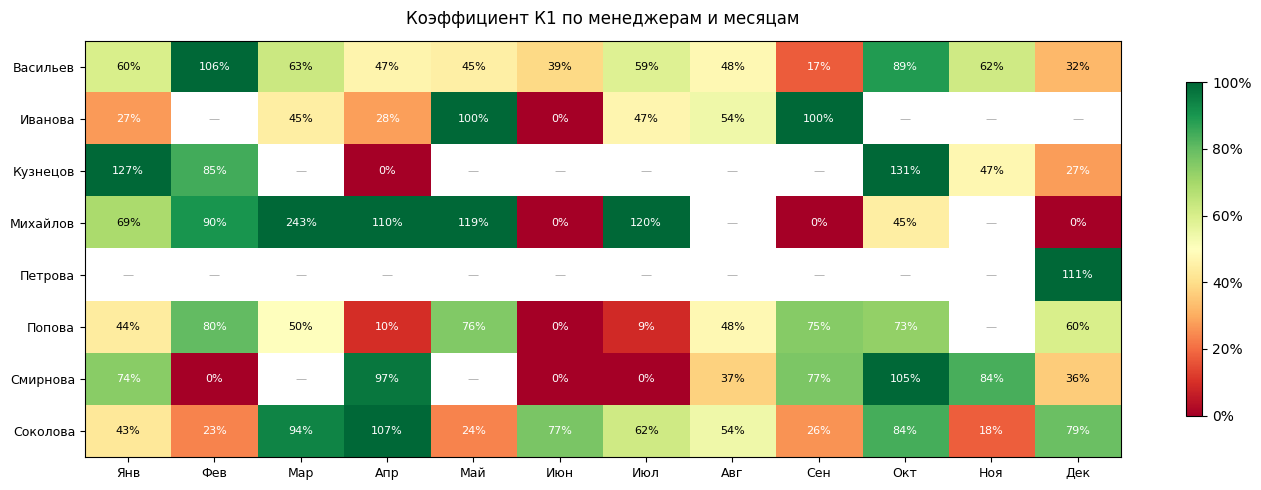

График сохранён: k1_heatmap.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

managers_list = [am for am in k1_am_year['AM'].tolist() if am != 'без А/М']
short_m = [month_short[m] for m in target_months]

matrix = []
for am in managers_list:
    row_vals = []
    for tm in target_months:
        sh = month_short[tm]
        rv = k1_am_month[(k1_am_month['AM']==am) & (k1_am_month['target_month']==tm)]
        v  = rv['coefficient'].values[0] if len(rv) > 0 and pd.notna(rv['coefficient'].values[0]) else np.nan
        row_vals.append(v)
    matrix.append(row_vals)

mat = np.array(matrix, dtype=float)

fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.RdYlGn
im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(short_m))); ax.set_xticklabels(short_m, fontsize=9)
am_labels = [am.split()[0] for am in managers_list]
ax.set_yticks(range(len(am_labels))); ax.set_yticklabels(am_labels, fontsize=9)
for i in range(len(managers_list)):
    for j in range(len(short_m)):
        v = mat[i,j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0%}', ha='center', va='center',
                    fontsize=8, color='black' if 0.3<v<0.7 else 'white')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=8, color='#aaa')
plt.colorbar(im, ax=ax, format='{x:.0%}', shrink=0.8)
ax.set_title('Коэффициент К1 по менеджерам и месяцам', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('k1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('График сохранён: k1_heatmap.png')


## Итоговые цифры

In [13]:
print(f'=== ИТОГОВЫЙ РЕЗУЛЬТАТ ===')
print(f'К1 (пролонгация в 1-й месяц):  {k1_year["coefficient"]:.1%}')
print(f'    Пролонгировано: {int(k1_year["prolonged_projects"])} из {int(k1_year["total_projects"])} проектов')
print(f'    Пролонг. сумма: {k1_year["prolonged_sum"]:,.0f} руб')
print(f'    Базовая сумма:  {k1_year["base_sum"]:,.0f} руб')
print()
print(f'К2 (пролонгация во 2-й месяц): {k2_year["coefficient"]:.1%}')
print(f'    Пролонгировано: {int(k2_year["prolonged_projects"])} из {int(k2_year["total_projects"])} проектов')
print(f'    Пролонг. сумма: {k2_year["prolonged_sum"]:,.0f} руб')
print(f'    Базовая сумма:  {k2_year["base_sum"]:,.0f} руб')


=== ИТОГОВЫЙ РЕЗУЛЬТАТ ===
К1 (пролонгация в 1-й месяц):  54.0%
    Пролонгировано: 159 из 335 проектов
    Пролонг. сумма: 18,855,551 руб
    Базовая сумма:  34,945,544 руб

К2 (пролонгация во 2-й месяц): 5.4%
    Пролонгировано: 16 из 173 проектов
    Пролонг. сумма: 812,532 руб
    Базовая сумма:  15,124,060 руб
